In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os  

import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.callbacks import ReduceLROnPlateau, EarlyStopping,  ModelCheckpoint
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import cv2

In [14]:
train_df = pd.read_csv("dataset\sign_mnist_train\sign_mnist_train.csv")
test_df = pd.read_csv("dataset\sign_mnist_test\sign_mnist_test.csv")

In [15]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [16]:
x_train = train_df.iloc[:, 1:].values
y_train = train_df["label"].values

In [17]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [18]:
x_test = test_df.iloc[:, 1:].values
y_test = test_df["label"].values

In [19]:
print(f"Shape of x_ train is: {x_train.shape}")
print(f"Shape of x_ test is: {x_test.shape}")
print(f"Shape of y_train is: {y_train.shape}")
print(f"Shape of y_test is: {y_test.shape}")

Shape of x_ train is: (27455, 784)
Shape of x_ test is: (7172, 784)
Shape of y_train is: (27455,)
Shape of y_test is: (7172,)


In [20]:
# Normalize the data
x_train = x_train / 255
x_test = x_test / 255

In [21]:
# reshaping data from 1D into # 3D
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_train = x_train.reshape(x_train.shape[0],28,28,1)

In [22]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test :", np.unique(y_test))


Unique labels in y_train: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Unique labels in y_test : [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


The dataset contains images of letters A–Y (25 letters), **but skips the letter J**, which would have been class index 9.  
As a result:
- We have 24 total classes (A–I, K–Y), but their original class indices range from 0 to 24 with a missing class 9.
- This creates a **gap in the labels**
- To train a model correctly, we must remap the original labels (0–8, 10–24) to consecutive indices 0–23.
- After remapping, our labels should range from 0 to 23, matching the 24 classes expected by the model output.


In [23]:
print(f"Shape of x_ train is: {x_train.shape}")
print(f"Shape of x_ test is: {x_test.shape}")
print(f"Shape of y_train is: {y_train.shape}")
print(f"Shape of y_test is: {y_test.shape}")

Shape of x_ train is: (27455, 28, 28, 1)
Shape of x_ test is: (7172, 28, 28, 1)
Shape of y_train is: (27455,)
Shape of y_test is: (7172,)


In [24]:
from sklearn.preprocessing import LabelEncoder

#Create encoder and fit on all labels to ensure same mapping
encoder = LabelEncoder()
encoder.fit(np.concatenate([y_train, y_test]))

# Transform train and test separately
y_train = encoder.transform(y_train)
y_test = encoder.transform(y_test)

print("Unique labels in y_train after remapping:", np.unique(y_train))
print("Unique labels in y_test after remapping:", np.unique(y_test))


Unique labels in y_train after remapping: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique labels in y_test after remapping: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [25]:
y_train = tf.keras.utils.to_categorical(y_train, 24)
y_test = tf.keras.utils.to_categorical(y_test, 24)


In [26]:
print(f"Shape of x_ train is: {x_train.shape}")
print(f"Shape of x_ test is: {x_test.shape}")
print(f"Shape of y_train is: {y_train.shape}")
print(f"Shape of y_test is: {y_test.shape}")

Shape of x_ train is: (27455, 28, 28, 1)
Shape of x_ test is: (7172, 28, 28, 1)
Shape of y_train is: (27455, 24)
Shape of y_test is: (7172, 24)


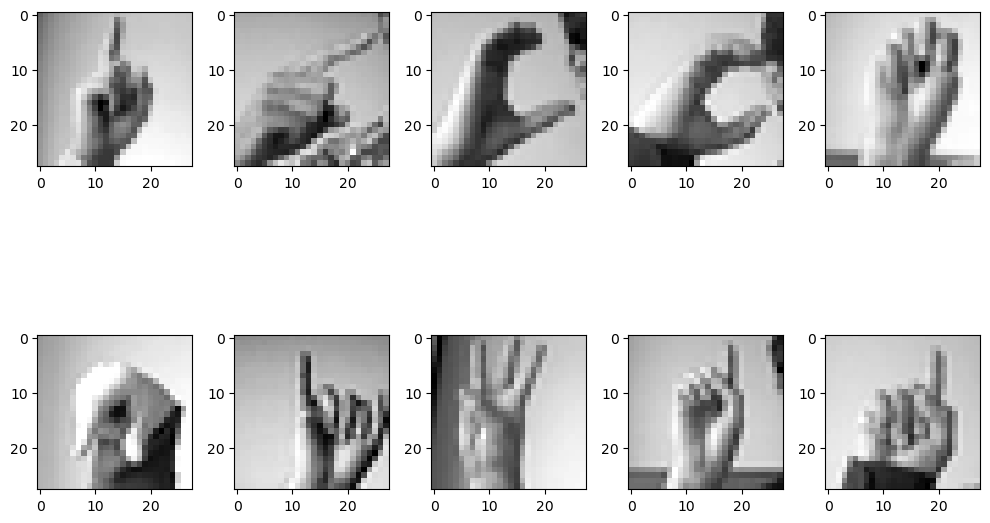

In [27]:
f, ax = plt.subplots(2,5) 
f.set_size_inches(10, 10)
k = 0
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(x_train[k].reshape(28, 28) , cmap = "gray")
        k += 1
    plt.tight_layout()    

In [28]:
datagen = ImageDataGenerator(
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # flipping changes sign meaning so it doesn't make sense to do it
        vertical_flip=False)  

datagen.fit(x_train)


In [37]:
# Model Training

model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (28,28,1)))
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))

model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))

model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())

model.add(Dense(units = 512 , activation = 'relu'))
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dense(units = 32 , activation = 'relu'))
model.add(Dense(units = 24 , activation = 'softmax'))

model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 7, 7, 128)         73856     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 4, 4, 128)       

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,  
    verbose=1
)

checkpoint = ModelCheckpoint(
    'cnn_model_03.keras',           
    monitor='val_loss', 
    save_best_only=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,                
    patience=3,               
    verbose=1
)

In [41]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 64) ,
                    epochs = 20, 
                    validation_data = (x_test, y_test) , 
                    callbacks=[early_stop, checkpoint, reduce_lr]
                    )

Epoch 1/20
429/429 [==============================] - ETA: 0s - loss: 0.9137 - accuracy: 0.6897
Epoch 1: val_loss improved from inf to 0.33312, saving model to cnn_model_03.keras
429/429 [==============================] - 40s 93ms/step - loss: 0.9137 - accuracy: 0.6897 - val_loss: 0.3331 - val_accuracy: 0.8765 - lr: 0.0010
Epoch 2/20
429/429 [==============================] - ETA: 0s - loss: 0.2609 - accuracy: 0.9117
Epoch 2: val_loss improved from 0.33312 to 0.07549, saving model to cnn_model_03.keras
429/429 [==============================] - 39s 90ms/step - loss: 0.2609 - accuracy: 0.9117 - val_loss: 0.0755 - val_accuracy: 0.9780 - lr: 0.0010
Epoch 3/20
429/429 [==============================] - ETA: 0s - loss: 0.1201 - accuracy: 0.9595
Epoch 3: val_loss improved from 0.07549 to 0.03707, saving model to cnn_model_03.keras
429/429 [==============================] - 42s 98ms/step - loss: 0.1201 - accuracy: 0.9595 - val_loss: 0.0371 - val_accuracy: 0.9923 - lr: 0.0010
Epoch 4/20
429/42

In [42]:
# Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

225/225 [==============================] - 5s 24ms/step - loss: 0.0122 - accuracy: 0.9986
Test accuracy: 0.9986
Test Loss: 0.0122


In [ ]:
model.save('cnn_model03.keras')
# model.save('cnn_model03.h5')

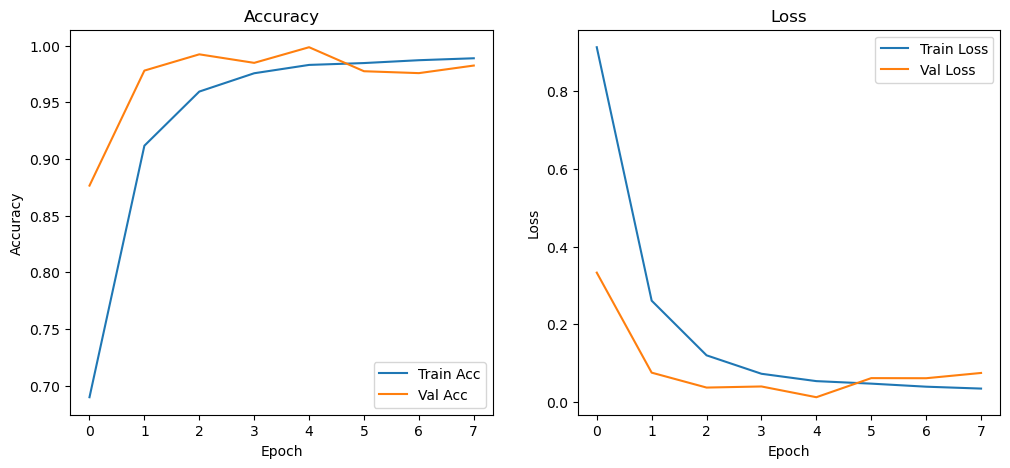

In [44]:
# Visualization

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [36]:
# Confusion Matrix

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

print(f"Classification Report:\n {classification_report(y_true, y_pred_classes)}")

225/225 [==============================] - 3s 11ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       245
           4       0.96      1.00      0.98       498
           5       1.00      1.00      1.00       247
           6       1.00      0.95      0.97       348
           7       1.00      1.00      1.00       436
           8       1.00      1.00      1.00       288
           9       1.00      1.00      1.00       331
          10       1.00      1.00      1.00       209
          11       1.00      0.96      0.98       394
          12       0.95      1.00      0.97       291
          13       1.00      1.00      1.00       246
          14       1.00      1.00      1.00       347
          15       1.00      1.00      1.00       164
 

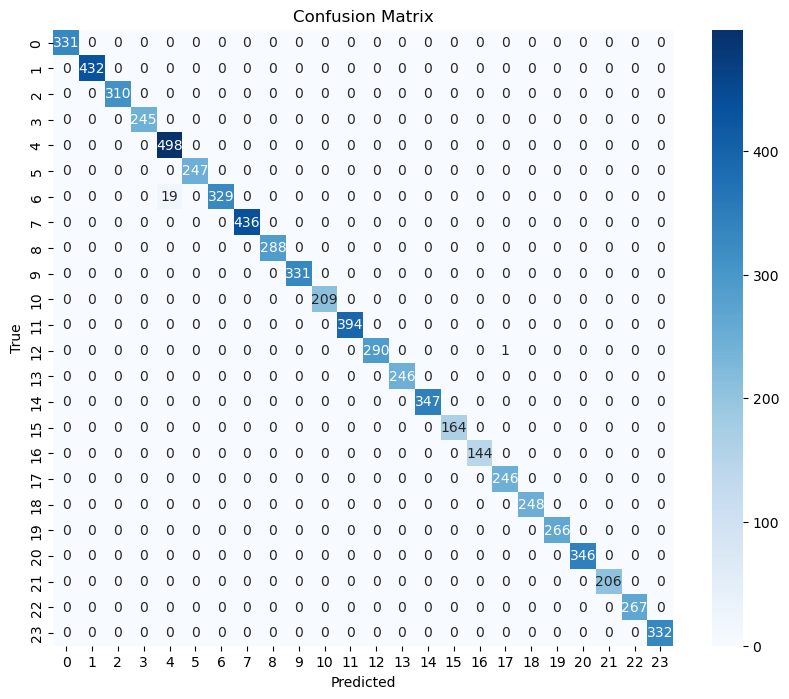

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()